In [3]:
from sircuitenum.quantize import gen_spaced_var_trans, well_spaced, unique_compact_extended, unique_harmonic, gen_cap_mat, gen_ind_mat, gen_w, secondary_decouple
from sircuitenum.quantize import _linearly_indep_cols, _vec_space_overlap, _islands_to_vectors, _indices_to_arr, gen_w, _linearly_indep_row_sets, _equal_up_to_column_shift_and_sign, _linearly_indep_rows
from sircuitenum import utils
from sircuitenum.visualize import draw_circuit_diagram
from sircuitenum import quantize

import sympy as sym

In [10]:
edges = [(1, 2), (3, 4), (1, 3), (2, 4)]
circuit = [("L_1", "C_1"), ("L_2", "C_2"), ("L_3",), ("J_1",)]
circuit = [("L_1", "C_1"), ("L_2", "C_2", "J_2"), ("L_3",), ("J_1",)]
# circuit = [("L", "C"), ("L", "C"), ("L",), ("J",)]
cMat = quantize.gen_cap_mat(circuit, edges)
lMat = quantize.gen_ind_mat(circuit, edges)
edges = utils.zero_start_edges(edges)
all_Z, var_types = quantize.gen_spaced_var_trans(circuit, edges)
Z0 = all_Z[0]
cTrans = Z0.transpose()*cMat*Z0
lTrans = Z0.transpose()*lMat*Z0
print(var_types)
display(cTrans)
lTrans

{'extended': [0, 1], 'harmonic': [2], 'sigma': [3]}


Matrix([
[C_1/9 + C_2 + C_{J_2},          -2*C_1/9,    C_1/3, 0],
[             -2*C_1/9, 4*C_1/9 + C_{J_1}, -2*C_1/3, 0],
[                C_1/3,          -2*C_1/3,      C_1, 0],
[                    0,                 0,        0, 0]])

Matrix([
[4/(9*L_3) + 1/L_2 + 1/(9*L_1), -2/(9*L_3) - 2/(9*L_1), -2/(3*L_3) + 1/(3*L_1), 0],
[       -2/(9*L_3) - 2/(9*L_1),  1/(9*L_3) + 4/(9*L_1),  1/(3*L_3) - 2/(3*L_1), 0],
[       -2/(3*L_3) + 1/(3*L_1),  1/(3*L_3) - 2/(3*L_1),          1/L_3 + 1/L_1, 0],
[                            0,                      0,                      0, 0]])

In [11]:
Z = secondary_decouple(Z0, var_types, cMat, lMat, return_instance=True)
display(Z)
display(Z.transpose()*cTrans*Z)
display(Z.transpose()*lTrans*Z)

Matrix([
[  0,   1, 0, 0],
[  1,   1, 0, 0],
[2/3, 1/3, 1, 0],
[  0,   0, 0, 1]])

Matrix([
[C_{J_1},                 C_{J_1},   0, 0],
[C_{J_1}, C_2 + C_{J_1} + C_{J_2},   0, 0],
[      0,                       0, C_1, 0],
[      0,                       0,   0, 0]])

Matrix([
[1/L_3,     0,         1/L_3, 0],
[    0, 1/L_2,             0, 0],
[1/L_3,     0, 1/L_3 + 1/L_1, 0],
[    0,     0,             0, 0]])

In [1]:
import itertools
import numpy as np
def secondary_decouple(Z0, var_types, cMat, lMat):

    cTrans = sym.simplify(Z0.transpose()*cMat*Z0)
    lTrans = sym.simplify(Z0.transpose()*lMat*Z0)
    eye = sym.eye(Z0.shape[0])
    comp = var_types.get("compact", [])
    n_comp = len(comp)
    ext = var_types.get("extended", [])
    n_ext = len(ext)
    harm = var_types.get("harmonic", [])
    n_harm = len(harm)

    # Zhe != 0
    Z2 = sym.eye(Z0.shape[0])
    # Zh != I
    Z3 = sym.eye(Z0.shape[0])
    varsZ2 = []
    varsZ3 = []
    for i in range(Z2.shape[0]):
        for j in range(Z2.shape[1]):
            if j in var_types["extended"] and i in var_types["harmonic"]:
                Z2[i,j] = sym.Symbol(f"Zeh{i}{j}", real=True)
                varsZ2.append(Z2[i,j])
            elif j in var_types["harmonic"] and i in var_types["harmonic"]:
                Z3[i,j] = sym.Symbol(f"Zh{i}{j}", real=True)
                varsZ3.append(Z3[i,j])
    
    Z = sym.simplify(Z2*Z3)
    vars = varsZ2+varsZ3
    n_vars = len(vars)

    cTrans2 = sym.simplify(Z*cTrans*Z)
    lTrans2 = sym.simplify(Z*lTrans*Z)
    # lTrans3 = Z0.transpose()*lMat*Z0


    # Try to set to zero as many coupling terms as possible
    # coupling_ce = []
    # coupling_ch = []
    # coupling_eh = []
    # coupling_hh = []
    coupling_c = []
    coupling_l = []
    for ic in comp:
        for ie in ext:
            # coupling_ce.append((1, ic, ie))
            coupling_c.append((1, ic, ie))
        for ih in harm:
            # coupling_ch.append((1, ic, ie))
            coupling_c.append((1, ic, ie))
    for ie in ext:
        for ih in harm:
            # coupling_eh.append((0, ie, ih))
            # coupling_eh.append((1, ie, ih))
            coupling_l.append((0, ie, ih))
            coupling_c.append((1, ie, ih))
    for ih in harm:
        for ih2 in harm:
            if ih2 < ih:
                # coupling_hh.append((0, ih, ih2))
                # coupling_hh.append((1, ih, ih2))
                coupling_l.append((0, ih, ih2))
                coupling_c.append((1, ih, ih2))
    for ie in ext:
        for ie2 in ext:
            if ie2 < ie:
                coupling_l.append((0, ie, ie2))
                coupling_c.append((1, ie, ie2))


    n_couple_c = len(coupling_c)
    n_couple_l = len(coupling_l)
    n_couple = n_couple_c + n_couple_l
    coupling_mats = [lTrans2, cTrans2]
    eq_l = [lTrans2[x[1],x[2]] for x in coupling_l]
    eq_c = [cTrans2[x[1],x[2]] for x in coupling_c]
    # Lambdify for numerical solving
    eq_la = [sym.lambdify(vars, eq) for eq in eq_l]
    eq_ca = [sym.lambdify(vars, eq) for eq in eq_c]
    for nz in range(n_couple, -1, -1):
        best_Z = None
        best_val = ""
        for nz_l in range(min(n_couple_l, nz), nz-n_couple_c-1, -1):
            nz_c = nz-nz_l
            for il in itertools.combinations(range(n_couple_l), nz_l):
                for ic in itertools.combinations(range(n_couple_c), nz_c):
                    eq = [eq_la[i] for i in il] + [eq_ca[i] for i in ic]
                    print(nz, nz_l, nz_c, il, ic)
                    print(eq)
                    # res = sym.solve(eq, vars, simplify=False, dict=True)
                    res = sym.nsolve(eq, vars, [np.random.random()]*n_vars, dict=True)
                    print(res)
                    # Is there a solution with no free symbols?
                    for sol in res:
                        # print([sym.simplify(val) for val in sol.values()])
                        # print([sym.simplify(val).free_symbols for val in sol.values()])
                        if all(len(sym.simplify(val).free_symbols) == 0 for val in sol.values()):
                            Ztest = sym.simplify(Z.subs(sol))
                            # Does the solution lead to an invertible transformation?
                            # print(Ztest)
                            # print("DET:", Ztest.det())
                            if Ztest.det() == 0:
                                continue
                            val, Z_perm = quantize.H_hash(Ztest, var_types, Ztest.transpose()*cMat*Ztest,
                                                          Ztest.transpose()*cMat*Ztest, wJ=None)
                            if val < best_val or best_Z is None:
                                best_val = val
                                best_Z = Ztest
            if best_val != "":
                return best_Z
    
    return eye


# def _no_param_dep(expr, tol=1e-09):

#     expr2a, _ = quantize.num_subs(quantize.num_subs(expr, "L")[0], "C", hermitify=False)
#     expr2b, _ = quantize.num_subs(quantize.num_subs(expr, "L")[0], "C", hermitify=False)

#     if sym.Abs(expr2a-expr2b)
    
                    

        
    
    # Go backwards, in priority order
    # n_couple = len(coupling_ce) + len(coupling_eh) + len(coupling_hh)
    # for n_zero in list(range(n_couple))[::-1]:
    #     for 


In [7]:
circuit = [('J_1',), ('J_2',), ('C_1', 'L_1'), ('L_2',)]
edges = [(0, 2), (0, 3), (1, 3), (2, 3)]
trans, var_types = quantize.gen_spaced_var_trans(circuit, edges)
trans

Matrix([[0], [1], [0], [-1]])


[Matrix([
 [1,  1/3, -1/3, 1],
 [0,    0,  2/3, 1],
 [0,  1/3, -1/3, 1],
 [0, -2/3, -1/3, 1]]),
 Matrix([
 [1,  1/3, -1/3, 1],
 [0,    0,  2/3, 1],
 [0, -2/3, -1/3, 1],
 [0,  1/3, -1/3, 1]]),
 Matrix([
 [1,  0, -1/3, 1],
 [0,  0,  2/3, 1],
 [0,  1, -1/3, 1],
 [0, -1, -1/3, 1]])]

In [8]:
edges = [(1, 2), (3, 4), (1, 3), (2, 4)]
circuit = [("L_1", "C_1"), ("L_2", "C_2"), ("L_3",), ("J_1",)]
# circuit = [("L", "C"), ("L", "C"), ("L",), ("J",)]
cMat = quantize.gen_cap_mat(circuit, edges)
lMat = quantize.gen_ind_mat(circuit, edges)
edges = utils.zero_start_edges(edges)
all_Z, var_types = quantize.gen_spaced_var_trans(circuit, edges)
Z0 = all_Z[0]
cTrans = Z0.transpose()*cMat*Z0
lTrans = Z0.transpose()*lMat*Z0
print(var_types)
display(cTrans)
lTrans

Matrix([[1, 0], [-1, 0], [0, 1], [0, -1]])
{'extended': [0], 'harmonic': [1, 2], 'sigma': [3]}


Matrix([
[C_1/4 + C_2/4 + C_{J_1}, -C_1/2, -C_1/2 + C_2/2, 0],
[                 -C_1/2,    C_1,            C_1, 0],
[         -C_1/2 + C_2/2,    C_1,      C_1 + C_2, 0],
[                      0,      0,              0, 0]])

Matrix([
[1/(4*L_2) + 1/(4*L_1),    -1/(2*L_1), 1/(2*L_2) - 1/(2*L_1), 0],
[           -1/(2*L_1), 1/L_3 + 1/L_1,                 1/L_1, 0],
[1/(2*L_2) - 1/(2*L_1),         1/L_1,         1/L_2 + 1/L_1, 0],
[                    0,             0,                     0, 0]])

In [9]:
Z2 = sym.eye(4)
Z3 = sym.eye(4)
Z1 = sym.eye(4)
varsZ2 = []
varsZ3 = []
for i in range(Z2.shape[0]):
    for j in range(Z2.shape[1]):
        if j in var_types["extended"] and i in var_types["harmonic"]:
            Z2[i,j] = sym.Symbol(f"Zeh{i}{j}", real=True)
            Z1[i,j] = sym.Symbol(f"Zeh{i}{j}", real=True)
            varsZ2.append(Z2[i,j])
        elif j in var_types["harmonic"] and i in var_types["harmonic"]:
            Z3[i,j] = sym.Symbol(f"Zh{i}{j}", real=True)
            Z1[i,j] = sym.Symbol(f"Zh{i}{j}", real=True)
            varsZ3.append(Z3[i,j])
varsZ1 = varsZ2+varsZ3
c1 = sym.simplify(Z1.transpose()*cTrans*Z1)
c2 = sym.simplify(Z2.transpose()*cTrans*Z2)
c3 = sym.simplify(Z3.transpose()*cTrans*Z3)
l1 = sym.simplify(Z1.transpose()*lTrans*Z1)
l2 = sym.simplify(Z2.transpose()*lTrans*Z2)
l3 = sym.simplify(Z3.transpose()*lTrans*Z3)

In [119]:
c1[0,1].free_symbols

{C_1, C_2, Zeh10, Zeh20, Zh11, Zh21}

In [145]:
cap = [x for x in c1.free_symbols if "C" in str(x)]
collected = sym.collect(sym.expand(c1[0,1]), cap)
collected

C_1*(Zeh10*Zh11 + Zeh10*Zh21 + Zeh20*Zh11 + Zeh20*Zh21 - Zh11/2 - Zh21/2) + C_2*(Zeh20*Zh21 + Zh21/2)

In [146]:
cap

[C_2, C_{J_1}, C_1]

In [148]:
collected.coeff(cap[0]), collected.coeff(cap[2])

(Zeh20*Zh21 + Zh21/2,
 Zeh10*Zh11 + Zeh10*Zh21 + Zeh20*Zh11 + Zeh20*Zh21 - Zh11/2 - Zh21/2)

In [153]:
[collected.coeff(x) for x in cap if collected.coeff(x) != 0]

[Zeh20*Zh21 + Zh21/2,
 Zeh10*Zh11 + Zeh10*Zh21 + Zeh20*Zh11 + Zeh20*Zh21 - Zh11/2 - Zh21/2]

In [154]:
sym.solve([collected.coeff(x) for x in cap if collected.coeff(x) != 0], varsZ1, dict=True)

[{Zeh10: 1, Zeh20: -1/2}, {Zeh20: -1/2, Zh11: -Zh21}, {Zh11: 0, Zh21: 0}]

In [ ]:
ans = sym.solve(quantize.num_subs(c1[0,1])[0], [Z for Z in varsZ1 if Z in c1[0,1].free_symbols], dict=True)[0]
print(ans)
sym.simplify(c1.subs(ans))

{Zeh10: 0.05*(-1.53981106247814e+16*Zeh20*Zh11 - 3.10298299058808e+16*Zeh20*Zh21 + 7.69905531239071e+15*Zh11 - 116804328158959.0*Zh21)/(769905531239071.0*Zh11 + 769905531239070.0*Zh21)}


Matrix([
[(C_1*(0.2 - 0.4*Zeh20)*(Zh11 + 0.999999999999999*Zh21)**2*(1.53981106247814e+16*Zeh20*Zh11 + 3.10298299058808e+16*Zeh20*Zh21 - 7.69905531239071e+15*Zh11 + 116804328158959.0*Zh21) + 16.2436607411195*C_1*(769905531239071.0*Zh11 + 769905531239070.0*Zh21)*(0.496235740623998*Zeh20*Zh11 + Zeh20*Zh21 - 0.248117870311999*Zh11 + 0.003764259376002*Zh21)**2 + (Zh11 + 0.999999999999999*Zh21)**2*(769905531239071.0*Zh11 + 769905531239070.0*Zh21)*(4*C_1*Zeh20**2 - 4*C_1*Zeh20 + C_1 + 4*C_2*Zeh20**2 + 4*C_2*Zeh20 + C_2 + 4*C_{J_1}))/(4*(Zh11 + 0.999999999999999*Zh21)**2*(769905531239071.0*Zh11 + 769905531239070.0*Zh21)), Zh21*(-1.56317192810994e+15*C_1*Zeh20*Zh11 - 1.56317192810994e+15*C_1*Zeh20*Zh21 - 781585964054966.0*C_1*Zh11 - 781585964054966.0*C_1*Zh21 + 1.53981106247814e+15*C_2*Zeh20*Zh11 + 1.53981106247814e+15*C_2*Zeh20*Zh21 + 769905531239071.0*C_2*Zh11 + 769905531239070.0*C_2*Zh21)/(1.53981106247814e+15*Zh11 + 1.53981106247814e+15*Zh21), (-1.56317192810994e+15*C_1*Zeh20*Zh12*Zh21 - 1

In [115]:
ans = sym.solve((c1[0,1], c1[0,2]), varsZ1, dict=True)[0]
print(ans)
sym.simplify(c1.subs(ans))

{Zeh10: 1, Zeh20: -1/2}


Matrix([
[C_{J_1},                                                           0,                                                           0, 0],
[      0, C_1*Zh11*(Zh11 + Zh21) + Zh21*(C_1*Zh11 + Zh21*(C_1 + C_2)), C_1*Zh12*(Zh11 + Zh21) + Zh22*(C_1*Zh11 + Zh21*(C_1 + C_2)), 0],
[      0, C_1*Zh11*(Zh12 + Zh22) + Zh21*(C_1*Zh12 + Zh22*(C_1 + C_2)), C_1*Zh12*(Zh12 + Zh22) + Zh22*(C_1*Zh12 + Zh22*(C_1 + C_2)), 0],
[      0,                                                           0,                                                           0, 0]])

In [104]:
varsZ3

[Zh11, Zh12, Zh21, Zh22]

In [100]:
c1[1,2]

C_1*Zh12*(Zh11 + Zh21) + Zh22*(C_1*Zh11 + Zh21*(C_1 + C_2))

In [99]:
sym.solve(c1[1,2], varsZ3)

[(Zh21*(-C_1*Zh12 - C_1*Zh22 - C_2*Zh22)/(C_1*(Zh12 + Zh22)),
  Zh12,
  Zh21,
  Zh22)]

In [50]:
set([x for x in l1[0,2].free_symbols if "C" in str(x) or "L" in str(x)])

{L_1, L_2, L_3}

In [66]:
varsZ1

[Zeh10, Zeh20, Zh11, Zh12, Zh21, Zh22]

In [65]:
expr = c1[1,2]
find_constraints_for_symbol_free_system(expr, varsZ1, set([x for x in expr.free_symbols if "C" in str(x) or "L" in str(x)]))

{'solution': {Zh11: Zh21*(-C_1*Zh12 - C_1*Zh22 - C_2*Zh22)/(C_1*(Zh12 + Zh22))},
 'constraints': [{C_2: C}, {C_1: C}]}

In [39]:
from sympy import Eq, solve, simplify, S
def find_constraints_for_symbol_free_system(eqs, solve_vars, bad_syms):
    sols = solve(eqs, solve_vars, dict=True)

    for sol in sols:
        # Track whether any expressions still depend on bad symbols
        bad_exprs = {}
        
        for var, expr in sol.items():
            simplified_expr = simplify(expr)
            bads_in_expr = simplified_expr.free_symbols & bad_syms

            if bads_in_expr:
                bad_exprs[var] = (simplified_expr, bads_in_expr)

        if not bad_exprs:
            # Found a completely clean solution
            return {'solution': sol, 'constraints': None}

        # Try to build constraints to eliminate bad symbols from *all* expressions
        all_constraints = []
        for var, (expr, bads) in bad_exprs.items():
            for bad in bads:
                try:
                    # Use a placeholder constant to form an equation
                    placeholder = S('C')  # You can make this unique if needed
                    eq = Eq(expr, simplify(expr.subs(bad, placeholder)))
                    const_constraints = solve(eq, bad, dict=True)
                    if const_constraints:
                        all_constraints.extend(const_constraints)
                except Exception:
                    continue

        if all_constraints:
            return {'solution': sol, 'constraints': all_constraints}

    return None

In [33]:
_subs_all_symbols(c1[0,2])

0.291045167213476

In [25]:
def _subs_all_symbols(expr):
    for s in expr.free_symbols:
        expr = expr.subs(s, np.random.random())
    return expr
# def _is_zero_fast(expr, n_trials=10, tol=1e-9):

#     vals = []
#     for n in range(n_trials):
#         vals = {}
#         for s in expr.free_symbols:
#             vals

In [24]:
Z1

Matrix([
[    1,    0,    0, 0],
[Zeh10, Zh11, Zh12, 0],
[Zeh20, Zh21, Zh22, 0],
[    0,    0,    0, 1]])

In [10]:
l1

Matrix([
[   Zeh10**2/L_3 + Zeh20**2/L_2 + Zeh20/L_2 + 1/(4*L_2) + Zeh10**2/L_1 + 2*Zeh10*Zeh20/L_1 - Zeh10/L_1 + Zeh20**2/L_1 - Zeh20/L_1 + 1/(4*L_1), (L_2*Zh11*(L_3*(2*Zeh20 - 1) + 2*Zeh10*(L_1 + L_3)) + L_3*Zh21*(L_1 + L_2*(2*Zeh10 - 1) + 2*Zeh20*(L_1 + L_2)))/(2*L_1*L_2*L_3), (L_2*Zh12*(L_3*(2*Zeh20 - 1) + 2*Zeh10*(L_1 + L_3)) + L_3*Zh22*(L_1 + L_2*(2*Zeh10 - 1) + 2*Zeh20*(L_1 + L_2)))/(2*L_1*L_2*L_3), 0],
[(-L_2*L_3*Zh11/2 + L_2*Zeh10*(L_3*Zh21 + Zh11*(L_1 + L_3)) + L_3*Zeh20*(L_2*Zh11 + Zh21*(L_1 + L_2)) + L_3*Zh21*(L_1 - L_2)/2)/(L_1*L_2*L_3),                                                         Zh11**2/L_3 + Zh21**2/L_2 + Zh11**2/L_1 + 2*Zh11*Zh21/L_1 + Zh21**2/L_1,                                 (L_2*Zh12*(L_3*Zh21 + Zh11*(L_1 + L_3)) + L_3*Zh22*(L_2*Zh11 + Zh21*(L_1 + L_2)))/(L_1*L_2*L_3), 0],
[(-L_2*L_3*Zh12/2 + L_2*Zeh10*(L_3*Zh22 + Zh12*(L_1 + L_3)) + L_3*Zeh20*(L_2*Zh12 + Zh22*(L_1 + L_2)) + L_3*Zh22*(L_1 - L_2)/2)/(L_1*L_2*L_3),                                 (L_2*Z

In [150]:
sym.solve([l1[0,1], l1[0,2], l1[1,2]], varsZ2, dict=True)

[{Zeh10: L_3/(L_1 + L_2 + L_3),
  Zeh20: (-L_1 + L_2 - L_3)/(2*L_1 + 2*L_2 + 2*L_3)}]

In [11]:
sym.solve([c1[0,1], c1[0,2], c1[1,2]], varsZ2, simplify=False, rational=False)

{Zeh10: 1, Zeh20: -1/2}

In [18]:
res = sym.solve([c1[0,1]], varsZ2, simplify=False, rational=False, dict=True)
test = list(res[0].values())[0]
test

Zeh20*(-C_1*Zh11 - C_1*Zh21 - C_2*Zh21)/(C_1*Zh11 + C_1*Zh21) + (C_1*Zh11 + C_1*Zh21 - C_2*Zh21)/(2*C_1*Zh11 + 2*C_1*Zh21)

In [20]:
quantize.num_subs(sym.simplify(test))[0]

0.301123374953356*(-2*Zeh20*(1.66044897735836*Zh11 + 3.48482906097525*Zh21) + 1.66044897735836*Zh11 - 0.163931106258519*Zh21)/(Zh11 + Zh21)

In [126]:
display(c2)
display(l2)

Matrix([
[C_1*Zeh10**2 + 2*C_1*Zeh10*Zeh20 - C_1*Zeh10 + C_1*Zeh20**2 - C_1*Zeh20 + C_1/4 + C_2*Zeh20**2 + C_2*Zeh20 + C_2/4 + C_{J_1}, C_1*(Zeh10 + Zeh20 - 1/2), C_1*Zeh10 - C_1/2 + C_2/2 + Zeh20*(C_1 + C_2), 0],
[                                                                                                   C_1*(Zeh10 + Zeh20 - 1/2),                       C_1,                                           C_1, 0],
[                                                                               C_1*Zeh10 - C_1/2 + C_2/2 + Zeh20*(C_1 + C_2),                       C_1,                                     C_1 + C_2, 0],
[                                                                                                                           0,                         0,                                             0, 0]])

Matrix([
[Zeh10**2/L_3 + Zeh20**2/L_2 + Zeh20/L_2 + 1/(4*L_2) + Zeh10**2/L_1 + 2*Zeh10*Zeh20/L_1 - Zeh10/L_1 + Zeh20**2/L_1 - Zeh20/L_1 + 1/(4*L_1), Zeh10/L_3 + Zeh10/L_1 + Zeh20/L_1 - 1/(2*L_1), (L_1 + L_2*(2*Zeh10 - 1) + 2*Zeh20*(L_1 + L_2))/(2*L_1*L_2), 0],
[                                                                                            Zeh10/L_3 + Zeh10/L_1 + Zeh20/L_1 - 1/(2*L_1),                         (L_1 + L_3)/(L_1*L_3),                                                       1/L_1, 0],
[                                                                              (L_1 + L_2*(2*Zeh10 - 1) + 2*Zeh20*(L_1 + L_2))/(2*L_1*L_2),                                         1/L_1,                                       (L_1 + L_2)/(L_1*L_2), 0],
[                                                                                                                                        0,                                             0,                                                 

In [127]:
res = sym.solve([l2[0,1], l2[0,2]], vars, dict=True)
res

[{Zeh10: L_3/(L_1 + L_2 + L_3),
  Zeh20: (-L_1 + L_2 - L_3)/(2*L_1 + 2*L_2 + 2*L_3)}]

In [142]:
c2b, _ = quantize.num_subs(c2, "C")
# res = sym.solve([c3[0,1], c3[0,2], c3[1,2]], vars, dict=True)
# res = sym.solve([c3[0,1], c3[0,2]], vars, dict=True)
res = sym.solve([c2b[0,1], c2b[0,2]], varsZ2, dict=False)
# sym.simplify(res[0][list(res[0].keys())[0]])
res

{Zeh10: 0.999999999999999, Zeh20: -0.500000000000000}

In [110]:
cTrans

Matrix([
[C_1/4 + C_2/4 + C_{J_1}, -C_1/2, -C_1/2 + C_2/2, 0],
[                 -C_1/2,    C_1,            C_1, 0],
[         -C_1/2 + C_2/2,    C_1,      C_1 + C_2, 0],
[                      0,      0,              0, 0]])

In [103]:
sym.simplify(c3)

Matrix([
[         C_1/4 + C_2/4 + C_{J_1},                            -C_1*Zh11/2 - Zh21*(C_1 - C_2)/2,                            -C_1*Zh12/2 - Zh22*(C_1 - C_2)/2, 0],
[-C_1*Zh11/2 - Zh21*(C_1 - C_2)/2, C_1*Zh11*(Zh11 + Zh21) + Zh21*(C_1*Zh11 + Zh21*(C_1 + C_2)), C_1*Zh12*(Zh11 + Zh21) + Zh22*(C_1*Zh11 + Zh21*(C_1 + C_2)), 0],
[-C_1*Zh12/2 - Zh22*(C_1 - C_2)/2, C_1*Zh11*(Zh12 + Zh22) + Zh21*(C_1*Zh12 + Zh22*(C_1 + C_2)), C_1*Zh12*(Zh12 + Zh22) + Zh22*(C_1*Zh12 + Zh22*(C_1 + C_2)), 0],
[                               0,                                                           0,                                                           0, 0]])

In [122]:
c3b, _ = quantize.num_subs(c3, "C")
# res = sym.solve([c3[1,2]], varsZ3, dict=False)
# res = sym.solve([c3[0,1], c3[0,2]], varsZ3, dict=False)
# res = sym.solve([c3b[0,1], c3b[0,2]], varsZ3, dict=False)
res = sym.solve([c3[0,1], c3[0,2]], varsZ3, dict=False)
res

{Zh11: Zh21*(-C_1 + C_2)/C_1, Zh12: Zh22*(-C_1 + C_2)/C_1}

In [118]:
l3b, _ = quantize.num_subs(l3, "L")
res = sym.solve([l3[0,1],l3[0,2]], varsZ3, dict=False)
res

{Zh11: Zh21*(L_1 - L_2)/L_2, Zh12: Zh22*(L_1 - L_2)/L_2}

In [100]:
res = sym.solve([c3[0,1], c3[0,2], c3[1,2]], vars, dict=False)
res

[]

In [79]:
res[0][0].free_symbols

set()

In [41]:
lMat

Matrix([
[1/L_3 + 1/L_1, -1/L_1,        -1/L_3,    0.0],
[       -1/L_1,  1/L_1,           0.0,      0],
[       -1/L_3,    0.0, 1/L_3 + 1/L_2, -1/L_2],
[          0.0,      0,        -1/L_2,  1/L_2]])

In [ ]:
circuit = [("C", "L1"), ("J", "L2")]
edges = [(1, 2), (1, 3)]
edges = utils.zero_start_edges(edges)
cMat = quantize.gen_cap_mat(circuit, edges)
lMat = quantize.gen_ind_mat(circuit, edges)
wJ = quantize.gen_w(circuit, edges, "J")
Z0 = sym.simplify(sym.Matrix([[1/2, 0, 1],
                            [0, 1, 1],
                            [-1/2, 0, 1]]), rational=True)

cTrans = Z0.transpose()*cMat*Z0
lTrans = Z0.transpose()*lMat*Z0
cTrans

Matrix([
[0.25*C + 1.0*C_{J}, -0.5*C, 0],
[            -0.5*C,      C, 0],
[                 0,      0, 0]])

In [18]:
vars = sym.symbols("Zh11, Zhe11")
Z2 = sym.eye(3)
Z2[1,1] = vars[0]
Z2[1,0] = vars[1]
Z2

Matrix([
[    1,    0, 0],
[Zhe11, Zh11, 0],
[    0,    0, 1]])

In [22]:
test = sym.simplify(Z2.transpose()*cTrans*Z2)
test

Matrix([
[C*Zhe11**2 - 1.0*C*Zhe11 + 0.25*C + 1.0*C_{J}, C*Zh11*(Zhe11 - 0.5), 0],
[                         C*Zh11*(Zhe11 - 0.5),            C*Zh11**2, 0],
[                                            0,                    0, 0]])

In [27]:
sym.solve(test[0,1], vars, dict=True)

[{Zh11: 0.0}, {Zhe11: 0.500000000000000}]

# Test all 3 Node

In [3]:
db_path = "/Users/eweissler/Library/CloudStorage/OneDrive-UCB-O365/Circuit Enumeration/circuits_4_nodes_7_elems.db"
df = utils.get_unique_qubits(db_path, 3)

In [7]:
for i, row in df.iterrows():
    gen_spaced_var_trans(row.circuit, row.edges)

AssertionError: 

# Final Function

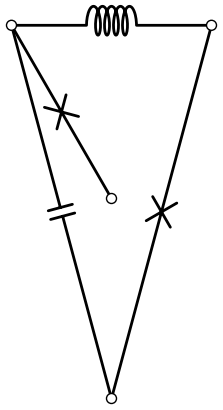

{'compact': [0, 1], 'harmonic': [2], 'sigma': [3]}
---------


Matrix([
[-1/2,  0,  0, 1],
[ 1/2,  0, -1, 1],
[-1/2,  0, -1, 1],
[-1/2, -1,  0, 1]])

Matrix([
[0,   1,   -1,  0],
[1,   0,    0, -1],
[1,   0,   -1,  0],
[1, 1/2, -1/2,  0]])

Matrix([
[C + C_{J},     0, -C, 0],
[        0, C_{J},  0, 0],
[       -C,     0,  C, 0],
[        0,     0,  0, 0]])

Matrix([
[0, 0,   0, 0],
[0, 0,   0, 0],
[0, 0, 1/L, 0],
[0, 0,   0, 0]])

Matrix([
[1, 0, 0, 0],
[0, 1, 0, 0]])

In [5]:
# Bifluxon
edges = [(1, 2), (1, 3), (2, 3), (1, 4)]
circuit = [("C",), ("L",), ("J",), ("J",)]
trans, var_types = gen_spaced_var_trans(circuit, edges)
draw_circuit_diagram(circuit, edges)
cMat = gen_cap_mat(circuit, utils.zero_start_edges(edges))
lMat = gen_ind_mat(circuit, utils.zero_start_edges(edges))
wJ = gen_w(circuit, edges, "J")
print(var_types)
for Z in trans:
    print("---------")
    display(Z)
    display(Z.inv())
    display(Z.transpose()*cMat*Z)
    display(Z.transpose()*lMat*Z)
    display(wJ.transpose()*Z)


In [3]:
edges = [(1, 2), (1, 3), (2, 3), (1, 4)]
circuit = [("C",), ("L",), ("J",), ("J",)]
trans = gen_spaced_var_trans(circuit, edges)
cMat = gen_cap_mat(circuit, utils.zero_start_edges(edges))
lMat = gen_ind_mat(circuit, utils.zero_start_edges(edges))
wJ = gen_w(circuit, edges, "J")
for Z in trans:
    print("---------")
    display(Z)
    # display(Z.inv())
    display(Z.transpose()*cMat*Z)
    display(Z.transpose()*lMat*Z)
    display(wJ.transpose()*Z)


---------


Matrix([
[0,  1/2, 1],
[1,  1/2, 1],
[0,  1/2, 1],
[0, -1/2, 1]])

Matrix([
[C + C_{J},     0, 0],
[        0, C_{J}, 0],
[        0,     0, 0]])

Matrix([
[0, 0, 0],
[0, 0, 0],
[0, 0, 0]])

Matrix([
[1, 0, 0],
[0, 1, 0]])

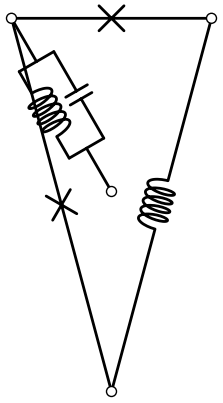

---------


Matrix([
[ 0,  1/3,  1/2, 1],
[-1, -2/3,  1/2, 1],
[-1,  1/3,  1/2, 1],
[ 0,    0, -1/2, 1]])

Matrix([
[  1,   0,   -1,   0],
[  0,  -1,    1,   0],
[  1, 1/3, -1/3,  -1],
[1/2, 1/6, -1/6, 1/2]])

Matrix([
[2*C_{J},       C_{J},   0, 0],
[  C_{J}, C/9 + C_{J}, C/3, 0],
[      0,         C/3,   C, 0],
[      0,           0,   0, 0]])

Matrix([
[0,        0,       0, 0],
[0, 10/(9*L), 1/(3*L), 0],
[0,  1/(3*L),     1/L, 0],
[0,        0,       0, 0]])

...

Matrix([
[ 0,  0,  1/2, 1],
[-1, -1,  1/2, 1],
[-1,  1,  1/2, 1],
[ 0,  0, -1/2, 1]])

Matrix([
[  1, -1/2, -1/2,   0],
[  0, -1/2,  1/2,   0],
[  1,    0,    0,  -1],
[1/2,    0,    0, 1/2]])

Matrix([
[2*C_{J},       0, 0, 0],
[      0, 2*C_{J}, 0, 0],
[      0,       0, C, 0],
[      0,       0, 0, 0]])

Matrix([
[0,   0,   0, 0],
[0, 4/L,   0, 0],
[0,   0, 1/L, 0],
[0,   0,   0, 0]])

Matrix([
[1,  1, 0, 0],
[1, -1, 0, 0]])

In [3]:
# Bifluxon
edges = [(1, 2), (1, 3), (2, 3), (1, 4)]
circuit = [("J",), ("J",), ("L",), ("C", "L")]
trans, var_types = gen_spaced_var_trans(circuit, edges)
draw_circuit_diagram(circuit, edges)
cMat = gen_cap_mat(circuit, utils.zero_start_edges(edges))
lMat = gen_ind_mat(circuit, utils.zero_start_edges(edges))
wJ = gen_w(circuit, edges, "J")
for Z in trans:
    print("---------")
    display(Z)
    display(Z.inv())
    display(Z.transpose()*cMat*Z)
    display(Z.transpose()*lMat*Z)
    display(wJ.transpose()*Z)


In [ ]:
# Bifluxon
edges = [(1, 2), (1, 3), (2, 3)]
circuit = [("J",), ("J",), ("L",)]
trans = gen_spaced_var_trans(circuit, edges)
cMat = gen_cap_mat(circuit, utils.zero_start_edges(edges))
                   
lMat = gen_ind_mat(circuit, utils.zero_start_edges(edges))
wJ = gen_w(circuit, edges, "J")
for Z in trans:
    print("---------")
    display(Z)
    display(Z.inv())
    display(Z.transpose()*cMat*Z)
    display(Z.transpose()*lMat*Z)
    display(wJ.transpose()*Z)


---------


Matrix([
[ 2/3,  1/3, 1],
[-1/3, -2/3, 1],
[-1/3,  1/3, 1]])

Matrix([
[  1,   0,  -1],
[  0,  -1,   1],
[1/3, 1/3, 1/3]])

Matrix([
[2*C_{J}, C_{J}, 0],
[  C_{J}, C_{J}, 0],
[      0,     0, 0]])

Matrix([
[0,   0, 0],
[0, 1/L, 0],
[0,   0, 0]])

...

Matrix([
[ 2/3,  0, 1],
[-1/3, -1, 1],
[-1/3,  1, 1]])

Matrix([
[  1, -1/2, -1/2],
[  0, -1/2,  1/2],
[1/3,  1/3,  1/3]])

Matrix([
[2*C_{J},       0, 0],
[      0, 2*C_{J}, 0],
[      0,       0, 0]])

Matrix([
[0,   0, 0],
[0, 4/L, 0],
[0,   0, 0]])

Matrix([
[1,  1, 0],
[1, -1, 0]])

In [3]:
# Zero -pi
edges = [(1, 2), (3, 4), (1, 4), (2, 3), (1, 3), (2, 4)]
circuit = [("J",), ("J",), ("L",), ("L",), ("C",), ("C",)]
trans = gen_spaced_var_trans(circuit, edges)
cMat = gen_cap_mat(circuit, utils.zero_start_edges(edges))
lMat = gen_ind_mat(circuit, utils.zero_start_edges(edges))
wJ = gen_w(circuit, edges, "J")
for Z in trans:
    print("---------")
    display(Z)
    display(Z.inv())
    display(Z.transpose()*cMat*Z)
    display(Z.transpose()*lMat*Z)
    display(wJ.transpose()*Z)

---------


Matrix([
[-1/2,  1/2,  1/2, 1],
[ 1/2, -1/2,  1/2, 1],
[ 1/2,    0, -1/2, 1],
[-1/2,    0, -1/2, 1]])

Matrix([
[  0,   0,    1,   -1],
[  1,  -1,    1,   -1],
[1/2, 1/2, -1/2, -1/2],
[1/4, 1/4,  1/4,  1/4]])

Matrix([
[2*C + 2*C_{J},  -C - C_{J},   0, 0],
[   -C - C_{J}, C/2 + C_{J},   0, 0],
[            0,           0, 2*C, 0],
[            0,           0,   0, 0]])

Matrix([
[0,       0,   0, 0],
[0, 1/(2*L),   0, 0],
[0,       0, 2/L, 0],
[0,       0,   0, 0]])

...

Matrix([
[-1/2,  1/2,  1/2, 1],
[ 1/2, -1/2,  1/2, 1],
[ 1/2,  1/2, -1/2, 1],
[-1/2, -1/2, -1/2, 1]])

Matrix([
[-1/2,  1/2,  1/2, -1/2],
[ 1/2, -1/2,  1/2, -1/2],
[ 1/2,  1/2, -1/2, -1/2],
[ 1/4,  1/4,  1/4,  1/4]])

Matrix([
[2*C + 2*C_{J},       0,   0, 0],
[            0, 2*C_{J},   0, 0],
[            0,       0, 2*C, 0],
[            0,       0,   0, 0]])

Matrix([
[0,   0,   0, 0],
[0, 2/L,   0, 0],
[0,   0, 2/L, 0],
[0,   0,   0, 0]])

Matrix([
[-1, 1, 0, 0],
[ 1, 1, 0, 0]])

In [4]:
# Transmon Molecule
edges = [(1, 2), (3, 4), (1, 3), (2, 4)]
circuit = [("J",), ("J",), ("C",), ("C",)]
trans = gen_spaced_var_trans(circuit, edges)
cMat = gen_cap_mat(circuit, utils.zero_start_edges(edges))
lMat = gen_ind_mat(circuit, utils.zero_start_edges(edges))
wJ = gen_w(circuit, edges, "J")
for Z in trans:
    print("---------")
    display(Z)
    display(Z.inv())
    display(Z.transpose()*cMat*Z)
    display(Z.transpose()*lMat*Z)
    display(wJ.transpose()*Z)

---------


Matrix([
[ 1/2,    0,  1/2, 1],
[-1/2,    0,  1/2, 1],
[   0,  1/2, -1/2, 1],
[   0, -1/2, -1/2, 1]])

Matrix([
[  1,  -1,    0,    0],
[  0,   0,    1,   -1],
[1/2, 1/2, -1/2, -1/2],
[1/4, 1/4,  1/4,  1/4]])

Matrix([
[C/2 + C_{J},        -C/2,   0, 0],
[       -C/2, C/2 + C_{J},   0, 0],
[          0,           0, 2*C, 0],
[          0,           0,   0, 0]])

Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]])

Matrix([
[1, 0, 0, 0],
[0, 1, 0, 0]])

In [5]:
# Big old LC
edges = [(1, 2), (3, 4), (1, 3), (2, 4)]
circuit = [("L",), ("L",), ("C",), ("C",)]
trans = gen_spaced_var_trans(circuit, edges)
cMat = gen_cap_mat(circuit, utils.zero_start_edges(edges))
lMat = gen_ind_mat(circuit, utils.zero_start_edges(edges))
# wJ = gen_w(circuit, edges, "J")
for Z in trans:
    print("---------")
    display(Z)
    display(Z.inv())
    display(Z.transpose()*cMat*Z)
    display(Z.transpose()*lMat*Z)
    # display(wJ.transpose()*Z)

---------


Matrix([
[-1/2,  1/2,  1/2, 1],
[ 1/2,  1/2, -1/2, 1],
[ 1/2, -1/2,  1/2, 1],
[-1/2, -1/2, -1/2, 1]])

Matrix([
[-1/2,  1/2,  1/2, -1/2],
[ 1/2,  1/2, -1/2, -1/2],
[ 1/2, -1/2,  1/2, -1/2],
[ 1/4,  1/4,  1/4,  1/4]])

Matrix([
[2*C,   0, 0, 0],
[  0, 2*C, 0, 0],
[  0,   0, 0, 0],
[  0,   0, 0, 0]])

Matrix([
[2/L, 0,   0, 0],
[  0, 0,   0, 0],
[  0, 0, 2/L, 0],
[  0, 0,   0, 0]])

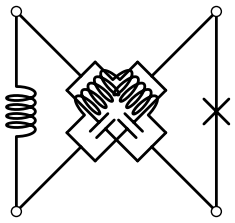

---------


Matrix([
[   0,  1/2,  3/4, 1],
[ 1/2, -1/2, -1/4, 1],
[   0,  1/2, -1/4, 1],
[-1/2, -1/2, -1/4, 1]])

Matrix([
[  0,    1,   0,   -1],
[  0, -1/2,   1, -1/2],
[  1,    0,  -1,    0],
[1/4,  1/4, 1/4,  1/4]])

Matrix([
[C/2 + C_{J},   0, -C/2, 0],
[          0, 2*C,    C, 0],
[       -C/2,   C,    C, 0],
[          0,   0,    0, 0]])

Matrix([
[ 1/(2*L),   0, -1/(2*L), 0],
[       0, 2/L,      1/L, 0],
[-1/(2*L), 1/L,      2/L, 0],
[       0,   0,        0, 0]])

...

Matrix([
[   0,  5/4, -1/4, 1],
[ 1/2, -3/4, -1/4, 1],
[   0,  1/4,  3/4, 1],
[-1/2, -3/4, -1/4, 1]])

Matrix([
[   0,    1,   0,   -1],
[ 1/2, -1/4,   0, -1/4],
[-1/2, -1/4,   1, -1/4],
[ 1/4,  1/4, 1/4,  1/4]])

Matrix([
[C/2 + C_{J}, -C/2, C/2, 0],
[       -C/2,  5*C,   C, 0],
[        C/2,    C,   C, 0],
[          0,    0,   0, 0]])

Matrix([
[ 1/(2*L), -1/(2*L), 1/(2*L), 0],
[-1/(2*L),      6/L,       0, 0],
[ 1/(2*L),        0,     2/L, 0],
[       0,        0,       0, 0]])

Matrix([[1, 0, 0, 0]])

In [5]:
# Multiple Harmonic Modes
edges = [(1, 2), (3, 4), (1, 3), (2, 4)]
circuit = [("L", "C"), ("L", "C"), ("L",), ("J",)]

trans, var_types = gen_spaced_var_trans(circuit, edges)
draw_circuit_diagram(circuit, edges)
cMat = gen_cap_mat(circuit, utils.zero_start_edges(edges))
lMat = gen_ind_mat(circuit, utils.zero_start_edges(edges))
wJ = gen_w(circuit, edges, "J")
for Z in trans:
    print("---------")
    display(Z)
    display(Z.inv())
    display(Z.transpose()*cMat*Z)
    display(Z.transpose()*lMat*Z)
    display(wJ.transpose()*Z)

# Bifluxon

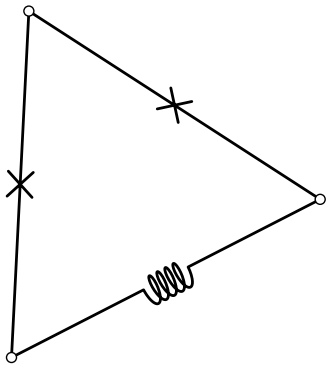

In [2]:
edges = [(1, 2), (1, 3), (2, 3)]
circuit = [("J",), ("J",), ("L",)]
cMat = gen_cap_mat(circuit, utils.zero_start_edges(edges))

draw_circuit_diagram(circuit, edges, layout="spring")

# match indices with array indices
edges = utils.zero_start_edges(edges)
n_nodes = utils.get_num_nodes(edges)
# labels of mode types
mode_types = []
# dynamical and nondynamical mode vectors
dy_modes = []
nd_modes = []

# sigma -- each set of connected components (should only be 1)
sig_vec = _islands_to_vectors(circuit, edges, [])
if len(sig_vec) > 1:
    print("--- WARNING: Multiple disconnected circuit segments ---")
# Free -- capacitively shunted islands
free_vec = _islands_to_vectors(circuit, edges, ["C"])
# Frozen -- inductively shunted islands
froz_vec = _islands_to_vectors(circuit, edges, ["L"])

# Compact -- J,C shunted islands
comp_vec = _islands_to_vectors(circuit, edges, ["J", "C"])
# Harmonic -- L,C shunted islands
harm_vec = _islands_to_vectors(circuit, edges, ["L", "C"])

# Extended -> must fill out the junction connectivity
# matrix. Minimize coupling, or maybe project to construct
# elements orthogonal to the harmonic vectors?
# All the compact variables will already be orthogonal from each other.
wJ = gen_w(circuit, edges, "J")
w_inv = sym.transpose(wJ.pinv())
w_inv = sym.transpose(wJ[:, :2].pinv())
jj_basis = comp_vec + [w_inv.col(i) for i in range(w_inv.shape[1]-1)]
cMat = gen_cap_mat(circuit, edges)
lMat = gen_ind_mat(circuit, edges)
# jj_basis = sym.GramSchmidt(jj_basis)

In [3]:
unique_compact(comp_vec, sym.Matrix.hstack(*sig_vec), sig_vec, free_vec, cMat, wJ)

[Matrix([
 [1],
 [0],
 [0]])]

# Zero Pi

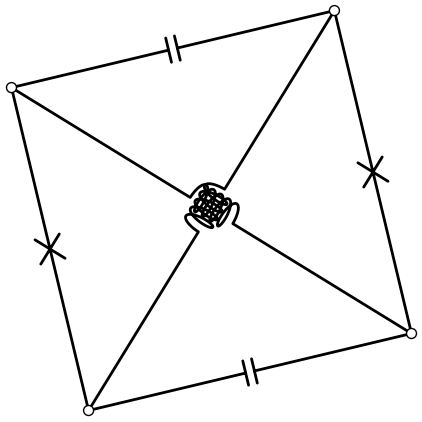

ShapeError: Matrix size mismatch: (2, 3) * (4, 2).

In [4]:
edges = [(1, 2), (3, 4), (1, 4), (2, 3), (1, 3), (2, 4)]
circuit = [("J",), ("J",), ("L",), ("L",), ("C",), ("C",)]
cMat = gen_cap_mat(circuit, utils.zero_start_edges(edges))

draw_circuit_diagram(circuit, edges, layout="spring")

# match indices with array indices
edges = utils.zero_start_edges(edges)
n_nodes = utils.get_num_nodes(edges)
# labels of mode types
mode_types = []
# dynamical and nondynamical mode vectors
dy_modes = []
nd_modes = []

# sigma -- each set of connected components (should only be 1)
sig_vec = _islands_to_vectors(circuit, edges, [])
if len(sig_vec) > 1:
    print("--- WARNING: Multiple disconnected circuit segments ---")
# Free -- capacitively shunted islands
free_vec = _islands_to_vectors(circuit, edges, ["C"])
# Frozen -- inductively shunted islands
froz_vec = _islands_to_vectors(circuit, edges, ["L"])

# Compact -- J,C shunted islands
JC_islands = _islands_to_vectors(circuit, edges, ["J", "C"])
wj = gen_w(circuit, edges, "J")
wj = wj[:, _linearly_indep_cols(wj)]
comp_vec, _, _ = _vec_space_overlap(JC_islands, wj.transpose().pinv())
# Verify spacing
assert all(well_spaced(wj.transpose()*v) for v in comp_vec)


# Harmonic -- L,C shunted islands
LC_islands = _islands_to_vectors(circuit, edges, ["L", "C"])
wc = gen_w(circuit, edges, "C")
wc = wc[:, _linearly_indep_cols(wc)]
wl = gen_w(circuit, edges, "L")
wl = wl[:, _linearly_indep_cols(wl)]
ovlp, _, _ = _vec_space_overlap(wc.transpose().pinv(), wl.transpose().pinv())
# Verify spacing
assert all(well_spaced(wl.transpose()*v) for v in ovlp)
harm_vec, _, _ = _vec_space_overlap(LC_islands, ovlp)
assert all(well_spaced(wl.transpose()*v) for v in harm_vec)


uc = unique_compact(comp_vec, sym.Matrix.hstack(*sig_vec), sig_vec, free_vec, cMat, wJ)
uh = unique_harmonic(harm_vec, sym.Matrix.hstack(*sig_vec), sig_vec, free_vec, froz_vec, cMat, lMat, wL)
ue = unique_extended(uc[0], uh[0], sym.Matrix.hstack(*sig_vec), sig_vec, free_vec, froz_vec, cMat, lMat, wJ)
# print(uc)
# print(uh)
# print(ue)
# display(cMat)

for Ze in ue:
    print('---------------')
    Z = sym.Matrix.hstack(uc[0], Ze, uh[0], *sig_vec)
    print("Z")
    display(Z)
    print("Z inv")
    display(Z.inv())
    print("C")
    display(Z.transpose()*cMat*Z)
    print("L")
    display(Z.transpose()*lMat*Z)
    print("wJ")
    display(wJ.transpose()*Z)
    # display(wL.transpose()*Z)

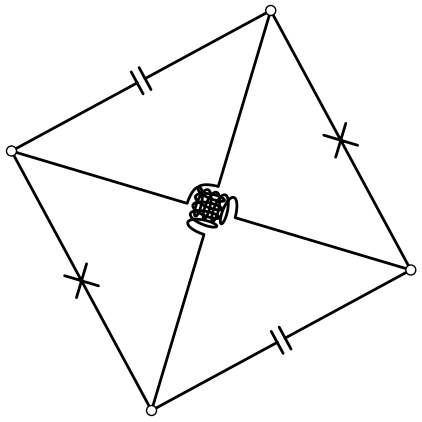

---------------
Z


Matrix([
[1,  1/2, 1, 1],
[0, -1/2, 1, 1],
[0,    0, 0, 1],
[1,    0, 0, 1]])

Z inv


Matrix([
[  0,   0,   -1,    1],
[  1,  -1,    1,   -1],
[1/2, 1/2, -1/2, -1/2],
[  0,   0,    1,    0]])

C


...

Matrix([
[2*C + 2*C_{J},       0,   0, 0],
[            0, 2*C_{J},   0, 0],
[            0,       0, 2*C, 0],
[            0,       0,   0, 0]])

L


Matrix([
[0,   0,   0, 0],
[0, 2/L,   0, 0],
[0,   0, 2/L, 0],
[0,   0,   0, 0]])

wJ


Matrix([
[ 1, 1, 0, 0],
[-1, 1, 0, 0]])

In [ ]:
edges = [(1, 2), (3, 4), (1, 4), (2, 3), (1, 3), (2, 4)]
circuit = [("J",), ("J",), ("L",), ("L",), ("C",), ("C",)]
cMat = gen_cap_mat(circuit, utils.zero_start_edges(edges))

draw_circuit_diagram(circuit, edges, layout="spring")

# match indices with array indices
edges = utils.zero_start_edges(edges)
n_nodes = utils.get_num_nodes(edges)
# labels of mode types
mode_types = []
# dynamical and nondynamical mode vectors
dy_modes = []
nd_modes = []

# sigma -- each set of connected components (should only be 1)
sig_vec = _islands_to_vectors(circuit, edges, [])
if len(sig_vec) > 1:
    print("--- WARNING: Multiple disconnected circuit segments ---")
# Free -- capacitively shunted islands
free_vec = _islands_to_vectors(circuit, edges, ["C"])
# Frozen -- inductively shunted islands
froz_vec = _islands_to_vectors(circuit, edges, ["L"])

# Compact -- J,C shunted islands
comp_vec = _islands_to_vectors(circuit, edges, ["J", "C"])
# Harmonic -- L,C shunted islands
harm_vec = _islands_to_vectors(circuit, edges, ["L", "C"])

# Extended -> must fill out the junction connectivity
# matrix. Minimize coupling, or maybe project to construct
# elements orthogonal to the harmonic vectors?
# All the compact variables will already be orthogonal from each other.
wJ = gen_w(circuit, edges, "J")
wL = gen_w(circuit, edges, "L")
w_inv = sym.transpose(wJ.pinv())
w_inv = sym.transpose(wJ[:, :2].pinv())
jj_basis = comp_vec + [w_inv.col(i) for i in range(w_inv.shape[1]-1)]
cMat = gen_cap_mat(circuit, edges)
lMat = gen_ind_mat(circuit, edges)
# jj_basis = sym.GramSchmidt(jj_basis)

uc = unique_compact(comp_vec, sym.Matrix.hstack(*sig_vec), sig_vec, free_vec, cMat, wJ)
uh = unique_harmonic(harm_vec, sym.Matrix.hstack(*sig_vec), sig_vec, free_vec, froz_vec, cMat, lMat, wL)
ue = unique_extended(uc[0], uh[0], sym.Matrix.hstack(*sig_vec), sig_vec, free_vec, froz_vec, cMat, lMat, wJ)
# print(uc)
# print(uh)
# print(ue)
# display(cMat)

for Ze in ue:
    print('---------------')
    Z = sym.Matrix.hstack(uc[0], Ze, uh[0], *sig_vec)
    print("Z")
    display(Z)
    print("Z inv")
    display(Z.inv())
    print("C")
    display(Z.transpose()*cMat*Z)
    print("L")
    display(Z.transpose()*lMat*Z)
    print("wJ")
    display(wJ.transpose()*Z)
    # display(wL.transpose()*Z)

# Transmon Moluecule

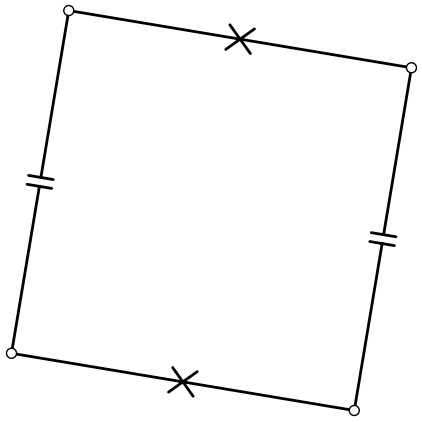

ShapeError: Matrix size mismatch: (2, 3) * (4, 4).

In [5]:
edges = [(1, 2), (3, 4), (1, 3), (2, 4)]
circuit = [("J",), ("J",), ("C",), ("C",)]
cMat = gen_cap_mat(circuit, utils.zero_start_edges(edges))

draw_circuit_diagram(circuit, edges, layout="spring")

# match indices with array indices
edges = utils.zero_start_edges(edges)
n_nodes = utils.get_num_nodes(edges)
# labels of mode types
mode_types = []
# dynamical and nondynamical mode vectors
dy_modes = []
nd_modes = []

# sigma -- each set of connected components (should only be 1)
sig_vec = _islands_to_vectors(circuit, edges, [])
if len(sig_vec) > 1:
    print("--- WARNING: Multiple disconnected circuit segments ---")
# Free -- capacitively shunted islands
free_vec = _islands_to_vectors(circuit, edges, ["C"])
# Frozen -- inductively shunted islands
froz_vec = _islands_to_vectors(circuit, edges, ["L"])

# Compact -- J,C shunted islands
JC_islands = _islands_to_vectors(circuit, edges, ["J", "C"])
wj = gen_w(circuit, edges, "J")
wj = wj[:, _linearly_indep_cols(wj)]
comp_vec, _, _ = _vec_space_overlap(JC_islands, wj.transpose().pinv())
# Verify spacing
assert all(well_spaced(wj.transpose()*v) for v in comp_vec)


# Harmonic -- L,C shunted islands
LC_islands = _islands_to_vectors(circuit, edges, ["L", "C"])
wc = gen_w(circuit, edges, "C")
wc = wc[:, _linearly_indep_cols(wc)]
wl = gen_w(circuit, edges, "L")
wl = wl[:, _linearly_indep_cols(wl)]
ovlp, _, _ = _vec_space_overlap(wc.transpose().pinv(), wl.transpose().pinv())
# Verify spacing
assert all(well_spaced(wl.transpose()*v) for v in ovlp)
harm_vec, _, _ = _vec_space_overlap(LC_islands, ovlp)
assert all(well_spaced(wl.transpose()*v) for v in harm_vec)

uc = unique_compact(comp_vec, sym.Matrix.hstack(*sig_vec, free_vec[0]), sig_vec, free_vec, cMat, wJ)

print(uc)

Z = sym.Matrix.hstack(uc[0], free_vec[0], *sig_vec)
display(Z.transpose()*cMat*Z)
display(wJ.transpose()*Z)

In [9]:
Z = sym.Matrix.hstack(uc[0], free_vec[0], *sig_vec)
display(Z.transpose()*cMat*Z)
display(wJ.transpose()*Z)

Matrix([
[C/2 + C_{J},        -C/2,   0, 0],
[       -C/2, C/2 + C_{J},   0, 0],
[          0,           0, 2*C, 0],
[          0,           0,   0, 0]])

Matrix([
[1, 0, 0, 0],
[0, 1, 0, 0]])

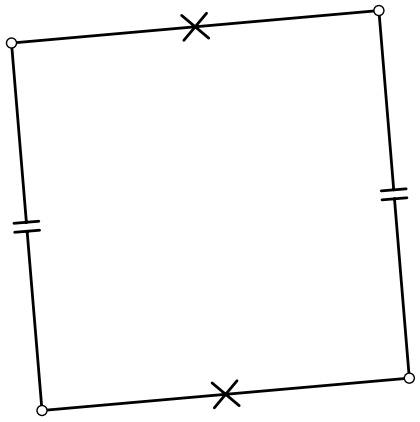

[Matrix([
 [ 1/2, 1/2],
 [-1/2, 1/2],
 [   0,   1],
 [   0,   0]])]

In [9]:
edges = [(1, 2), (3, 4), (1, 3), (2, 4)]
circuit = [("J",), ("J",), ("C",), ("C",)]
cMat = gen_cap_mat(circuit, utils.zero_start_edges(edges))

draw_circuit_diagram(circuit, edges, layout="spring")

# match indices with array indices
edges = utils.zero_start_edges(edges)
n_nodes = utils.get_num_nodes(edges)
# labels of mode types
mode_types = []
# dynamical and nondynamical mode vectors
dy_modes = []
nd_modes = []

# sigma -- each set of connected components (should only be 1)
sig_vec = _islands_to_vectors(circuit, edges, [])
if len(sig_vec) > 1:
    print("--- WARNING: Multiple disconnected circuit segments ---")
# Free -- capacitively shunted islands
free_vec = _islands_to_vectors(circuit, edges, ["C"])
# Frozen -- inductively shunted islands
froz_vec = _islands_to_vectors(circuit, edges, ["L"])

# Compact -- J,C shunted islands
comp_vec = _islands_to_vectors(circuit, edges, ["J", "C"])
# Harmonic -- L,C shunted islands
harm_vec = _islands_to_vectors(circuit, edges, ["L", "C"])

# Extended -> must fill out the junction connectivity
# matrix. Minimize coupling, or maybe project to construct
# elements orthogonal to the harmonic vectors?
# All the compact variables will already be orthogonal from each other.
wJ = gen_w(circuit, edges, "J")
w_inv = sym.transpose(wJ.pinv())
w_inv = sym.transpose(wJ[:, :2].pinv())
jj_basis = comp_vec + [w_inv.col(i) for i in range(w_inv.shape[1]-1)]
cMat = gen_cap_mat(circuit, edges)
lMat = gen_ind_mat(circuit, edges)
# jj_basis = sym.GramSchmidt(jj_basis)

unique_compact(comp_vec, sym.Matrix.hstack(*sig_vec, free_vec[0]), sig_vec, cMat, wJ)

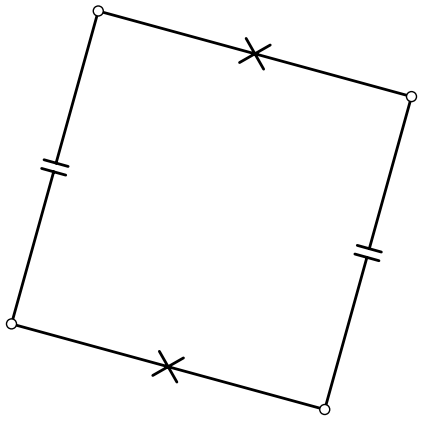

In [8]:
draw_circuit_diagram(circuit, edges, layout="spring")

# match indices with array indices
edges = utils.zero_start_edges(edges)
n_nodes = utils.get_num_nodes(edges)
# labels of mode types
mode_types = []
# dynamical and nondynamical mode vectors
dy_modes = []
nd_modes = []

# sigma -- each set of connected components (should only be 1)
sig_vec = _islands_to_vectors(circuit, edges, [], start_idx=0)
if len(sig_vec) > 1:
    print("--- WARNING: Multiple disconnected circuit segments ---")
# Free -- capacitively shunted islands
free_vec = _islands_to_vectors(circuit, edges, ["C"])
# Frozen -- inductively shunted islands
froz_vec = _islands_to_vectors(circuit, edges, ["L"])

# Compact -- J,C shunted islands
comp_vec = _islands_to_vectors(circuit, edges, ["J", "C"], 0)
# Harmonic -- L,C shunted islands
harm_vec = _islands_to_vectors(circuit, edges, ["L", "C"])

# Extended -> must fill out the junction connectivity
# matrix. Minimize coupling, or maybe project to construct
# elements orthogonal to the harmonic vectors?
# All the compact variables will already be orthogonal from each other.
w = gen_w(circuit, edges, "J")
w_inv = sym.transpose(w.pinv())
w_inv = sym.transpose(w[:, :2].pinv())
jj_basis = comp_vec + [w_inv.col(i) for i in range(w_inv.shape[1]-1)]
cMat = gen_cap_mat(circuit, edges)
lMat = gen_ind_mat(circuit, edges)
# jj_basis = sym.GramSchmidt(jj_basis)

In [9]:
Z = sym.Matrix([[0, 1/2, 1, 1],
                [1, 1/2, 1, 1],
                [1/2, 1, 0, 1],
                [1/2, 0, 0, 1]])
display(w.transpose()*Z)
ctrans = Z.transpose()*cMat*Z
ctrans

Matrix([
[-1, 0, 0, 0],
[ 0, 1, 0, 0]])

Matrix([
[0.5*C + C_{J},         0.5*C,   0, 0],
[        0.5*C, 0.5*C + C_{J},   0, 0],
[            0,             0, 2*C, 0],
[            0,             0,   0, 0]])

In [10]:
sym.nsimplify(Z)

Matrix([
[  0, 0.5, 1, 1],
[  1, 0.5, 1, 1],
[0.5,   1, 0, 1],
[0.5,   0, 0, 1]])

In [12]:
for Z in _compact_alignment_transformation(wT, 2):
    display(wT*Z)

NameError: name '_compact_alignment_transformation' is not defined

# 3 Junctions

In [18]:

def compact_alignment_transformation(wT:sym.Matrix, n_c:int):

    wc = wT[:, :n_c]

    # TODO:
    # Think about row magnitudes, we want the rows with the
    # smallest magnitude
    # Shouldn't matter

    # Try all different linearly independent row combinations
    row_sets = _linearly_indep_row_sets(wc)
    all_Zc = []
    for rows in row_sets:
        # Get the appropriate transformation for each set
        Zc = wc[rows, :].pinv()
        # Verify it's well-aligned
        if compact_well_aligned(wc*Zc, n_c):
            if not any(_equal_up_to_column_shift_and_sign(Zc, X) for X in all_Zc):
                all_Zc.append(Zc)

    # Return all possible transformations
    all_Z = []
    for Zc in all_Zc:
        Z = sym.eye(wT.shape[1])
        Z[:n_c, :n_c] = Zc
        all_Z.append(Z)

    return all_Z


def compact_well_aligned(wT: sym.Matrix, n_c: int):

    # Nothing to worry about here
    if n_c == 0:
        return True
    
    wc = wT[:, :n_c]
    rows, cols = wc.shape

    # 1 periodic variable -- is there a 1 or -1 there
    if n_c == 1:
        nz_entries = [sym.Abs(wc[i,0]) for i in range(rows) if wc[i,0].is_nonzero]
        if len(nz_entries) == 0:
            return False
        elif 1 in nz_entries:
            return True
        else:
            return False
        
    # 2 or more periodic variables --
    # Does each compact variable have at least one junction that
    # depends on it alone (among compact variables)
    else:
        # Select all rows with a single 1/-1 and rest 0's
        e_rows = []
        for i in range(wc.shape[0]):
            nz_entries = [sym.Abs(wc[i,j]) for j in range(cols) if wc[i,j].is_nonzero]
            if len(nz_entries) == 0:
                continue
            if len(nz_entries) == 1 and nz_entries[0] == 1:
                e_rows.append(i)

        # Check if all the single entry rows span the
        # number of compact variables: yes->well aligned
        return len(_linearly_indep_rows(wc[e_rows, :])) == n_c



In [19]:
for Z in compact_alignment_transformation(wT, 2):
    display(wT*Z)

Matrix([
[ 1,  0, 1, 0],
[ 0,  1, 0, 0],
[-1, -1, 1, 0]])

Matrix([
[ 1,  0, 1, 0],
[-1, -1, 0, 0],
[ 0,  1, 1, 0]])

Matrix([
[-1, -1, 1, 0],
[ 1,  0, 0, 0],
[ 0,  1, 1, 0]])

In [15]:
edges = [(1, 2), (2, 3), (3, 4), (4,1)]
edges = utils.zero_start_edges(edges)
circuit = [("J",), ("J","C"), ("J",), ("L",)]
Z = sym.nsimplify((sym.Matrix([[1, 0, 1, 1],
                                [0, -1/2, 0, 1],
                                [0, 1/2, 0, 1],
                                [1, 0, -1, 1]])), rational=True)
display(Z)
# display(Z.inv())
wj = gen_w(circuit, edges, "J")
display(wj.pinv().transpose())
wT = wj.transpose()*Z
wT

Matrix([
[1,    0,  1, 1],
[0, -1/2,  0, 1],
[0,  1/2,  0, 1],
[1,    0, -1, 1]])

Matrix([
[ 3/4,  1/2,  1/4],
[-1/4,  1/2,  1/4],
[-1/4, -1/2,  1/4],
[-1/4, -1/2, -3/4]])

Matrix([
[ 1, 1/2, 1, 0],
[ 0,  -1, 0, 0],
[-1, 1/2, 1, 0]])

Matrix([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])
Matrix([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])
Matrix([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])


Matrix([
[1.0,  1.5,  0,  0],
[  0, -1.0, -1,  0],
[  0,    0,  1, -1]])

Matrix([
[-0.5, -1.5,  0,  0],
[ 1.0,  1.0, -1,  0],
[   0,    0,  1, -1]])

Matrix([
[ 0.5, -1.0,  0,  0],
[-1.0,    0, -1,  0],
[   0,    0,  1, -1]])

In [41]:
ctrans = Z.transpose()*gen_cap_mat(circuit,edges)*Z
ltrans = Z.transpose()*gen_ind_mat(circuit,edges)*Z
display(ctrans)
display(ltrans)
display(ctrans[:3,:3].inv())

Matrix([
[C + 2*C_{J},  -C - C_{J},  -C_{J}, 0],
[ -C - C_{J}, C + 2*C_{J},   C_{J}, 0],
[     -C_{J},       C_{J}, 2*C_{J}, 0],
[          0,           0,       0, 0]])

Matrix([
[0, 0,   0, 0],
[0, 0,   0, 0],
[0, 0, 4/L, 0],
[0, 0,   0, 0]])

Matrix([
[(2*C + 3*C_{J})/(4*C*C_{J} + 4*C_{J}**2),   (2*C + C_{J})/(4*C*C_{J} + 4*C_{J}**2),                        1/(4*C + 4*C_{J})],
[  (2*C + C_{J})/(4*C*C_{J} + 4*C_{J}**2), (2*C + 3*C_{J})/(4*C*C_{J} + 4*C_{J}**2),                       -1/(4*C + 4*C_{J})],
[                       1/(4*C + 4*C_{J}),                       -1/(4*C + 4*C_{J}), (2*C + 3*C_{J})/(4*C*C_{J} + 4*C_{J}**2)]])

In [ ]:

for Z in compact_alignment_transformation(, 2):
    display(wj.transpose()*Z)

ShapeError: Matrix size mismatch: (3, 3) * (2, 2).

# Bifluxon

In [3]:
edges = [(1, 2), (1, 3), (2, 3)]
circuit = [("J",), ("J",), ("L",)]
cMat = gen_cap_mat(circuit, utils.zero_start_edges(edges))

In [4]:
# match indices with array indices
edges = utils.zero_start_edges(edges)
n_nodes = utils.get_num_nodes(edges)
# labels of mode types
mode_types = []
# dynamical and nondynamical mode vectors
dy_modes = []
nd_modes = []

# sigma -- each set of connected components (should only be 1)
sig_vec = _islands_to_vectors(circuit, edges, [], start_idx=0)
if len(sig_vec) > 1:
    print("--- WARNING: Multiple disconnected circuit segments ---")
# Free -- capacitively shunted islands
free_vec = _islands_to_vectors(circuit, edges, ["C"])
# Frozen -- inductively shunted islands
froz_vec = _islands_to_vectors(circuit, edges, ["L"])

# Compact -- J,C shunted islands
comp_vec = _islands_to_vectors(circuit, edges, ["J", "C"], 0)
# Harmonic -- L,C shunted islands
harm_vec = _islands_to_vectors(circuit, edges, ["L", "C"])

# Extended -> must fill out the junction connectivity
# matrix. Minimize coupling, or maybe project to construct
# elements orthogonal to the harmonic vectors?
# All the compact variables will already be orthogonal from each other.
w = gen_w(circuit, edges, "J")
w_inv = sym.transpose(w.pinv())
w_inv = sym.transpose(w[:, :2].pinv())
jj_basis = comp_vec + [w_inv.col(i) for i in range(w_inv.shape[1]-1)]
# jj_basis = sym.GramSchmidt(jj_basis)

In [5]:
w

Matrix([
[ 1,  1],
[-1,  0],
[ 0, -1]])

In [6]:
w_inv

Matrix([
[ 1/3,  1/3],
[-2/3,  1/3],
[ 1/3, -2/3]])

In [94]:
w_inv + sym.ones(3,2)*sym.Rational(1,6)

Matrix([
[ 1/2,  1/2],
[-1/2,  1/2],
[ 1/2, -1/2]])

In [95]:
w_inv2 = w_inv + sym.ones(3,2)*sym.Rational(1,6)

In [56]:
w2 = w.replace(-1, 0)
w2[3,1] = 1
w2[2,1] = 0
w2

Matrix([
[1, 0],
[0, 0],
[0, 0],
[0, 1]])

In [57]:
w.transpose()*sym.Matrix.hstack(*comp_vec)

Matrix([
[ 1, -1],
[-1,  1]])

In [58]:
ab = sym.symbols("a, b", real=True)
w_test*sym.Matrix(ab)

Matrix([
[ 0],
[-a],
[ b],
[-b]])

In [59]:
sym.Matrix(sym.symbols("c,", real=True))

Matrix([[c]])

In [60]:
harm_vec[0]*sym.Matrix(sym.symbols("c,", real=True))

Matrix([
[0],
[0],
[c],
[c]])

In [77]:
Z = sym.Matrix.hstack(comp_vec[0], sym.Symbol("x", real=True)*sig_vec[0] + w_inv*sym.Matrix(sym.symbols("a, b", real=True)), sym.Matrix.hstack(harm_vec[0])*sym.Matrix(sym.symbols("c,", real=True)), sig_vec[0])
Z

IndexError: list index out of range

In [ ]:
ctrans = sym.simplify(Z.transpose()*cMat*Z)
ctrans

In [102]:
Z = sym.Matrix.hstack(comp_vec[0]-sym.ones(3,1)*sym.Rational(1,2), sym.Symbol("x", real=True)*sig_vec[0] + w_inv*sym.Matrix(sym.symbols("a, b", real=True)), sig_vec[0])
display(Z)
display(Z.inv())

Matrix([
[ 1/2,    a/3 + b/3 + x, 1],
[-1/2, -2*a/3 + b/3 + x, 1],
[-1/2,  a/3 - 2*b/3 + x, 1]])

Matrix([
[  1,                   b/(a - b),                  -a/(a - b)],
[  0,                  -1/(a - b),                   1/(a - b)],
[1/2, (2*a - b + 6*x)/(6*a - 6*b), (a - 2*b - 6*x)/(6*a - 6*b)]])

In [86]:
Z = sym.Matrix.hstack(comp_vec[0], sym.Symbol("x", real=True)*sig_vec[0] + w*sym.Matrix(sym.symbols("a, b", real=True)), sig_vec[0])
Z

Matrix([
[1, a + b + x, 1],
[0,    -a + x, 1],
[0,    -b + x, 1]])

In [97]:
ctrans = sym.simplify(Z.transpose()*cMat*Z)
ctrans

Matrix([
[      2*C_{J},       C_{J}*(a + b), 0],
[C_{J}*(a + b), C_{J}*(a**2 + b**2), 0],
[            0,                   0, 0]])

In [87]:
ctrans = sym.simplify(Z.transpose()*cMat*Z)
ctrans

Matrix([
[        2*C_{J},                 3*C_{J}*(a + b), 0],
[3*C_{J}*(a + b), C_{J}*(5*a**2 + 8*a*b + 5*b**2), 0],
[              0,                               0, 0]])

In [99]:
ctrans = sym.simplify(Z.transpose()*cMat*Z)
ctrans

Matrix([
[      2*C_{J},       C_{J}*(a + b), 0],
[C_{J}*(a + b), C_{J}*(a**2 + b**2), 0],
[            0,                   0, 0]])

In [ ]:
sym.solve(ctrans[0,1], ab[1])

In [ ]:
for cv in comp_vec:
    display(sym.transpose(w)*cv)

# Look at case with three pronged Junction and a Free Mode

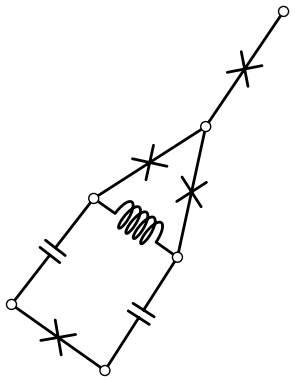

In [37]:
circuit = [ ("J",), ("J",), ("J",), ("L",), ("C",), ("C",), ("J",)]
edges = [(0, 1), (1, 2), (1, 3), (2, 3), (2, 4), (3, 5), (4, 5)]
draw_circuit_diagram(circuit, edges, layout="spring")

# match indices with array indices
edges = utils.zero_start_edges(edges)
n_nodes = utils.get_num_nodes(edges)
# labels of mode types
mode_types = []
# dynamical and nondynamical mode vectors
dy_modes = []
nd_modes = []

# sigma -- each set of connected components (should only be 1)
sig_vec = _islands_to_vectors(circuit, edges, [])
if len(sig_vec) > 1:
    print("--- WARNING: Multiple disconnected circuit segments ---")
# Free -- capacitively shunted islands
free_vec = _islands_to_vectors(circuit, edges, ["C"])
# Frozen -- inductively shunted islands
froz_vec = _islands_to_vectors(circuit, edges, ["L"])

# Compact -- J,C shunted islands
comp_vec = _islands_to_vectors(circuit, edges, ["J", "C"])
# Harmonic -- L,C shunted islands
harm_vec = _islands_to_vectors(circuit, edges, ["L", "C"])

# Extended -> must fill out the junction connectivity
# matrix. Minimize coupling, or maybe project to construct
# elements orthogonal to the harmonic vectors?
# All the compact variables will already be orthogonal from each other.
wj = gen_w(circuit, edges, "J")
wj_inv = sym.transpose(wj.pinv())

wc = gen_w(circuit, edges, "C")
wc_inv = sym.transpose(wc.pinv())

wl = gen_w(circuit, edges, "L")
wl_inv = sym.transpose(wl.pinv())

w = gen_w(circuit, edges, "J")
w_inv = sym.transpose(w[:, :2].pinv())
jj_basis = comp_vec + [w_inv.col(i) for i in range(w_inv.shape[1]-1)]
cMat = gen_cap_mat(circuit, edges)
lMat = gen_ind_mat(circuit, edges)
# jj_basis = sym.GramSchmidt(jj_basis)

In [38]:
for x in wl.transpose().nullspace():
    display(x.transpose())

Matrix([[1, 0, 0, 0, 0, 0]])

Matrix([[0, 1, 0, 0, 0, 0]])

Matrix([[0, 0, 1, 1, 0, 0]])

Matrix([[0, 0, 0, 0, 1, 0]])

Matrix([[0, 0, 0, 0, 0, 1]])

In [44]:
sym.Matrix.hstack(*wl.transpose().nullspace())

Matrix([
[1, 0, 0, 0, 0],
[0, 1, 0, 0, 0],
[0, 0, 1, 0, 0],
[0, 0, 1, 0, 0],
[0, 0, 0, 1, 0],
[0, 0, 0, 0, 1]])

In [47]:
wl_ns = sym.Matrix.hstack(*wl.transpose().nullspace())
wc_ns = sym.Matrix.hstack(*wc.transpose().nullspace())
ns = sym.Matrix.hstack(wl_ns, -wj_inv, *free_vec).nullspace()
cp_spaced = sym.Matrix.hstack(*ns).transpose()
display(cp_spaced)
for i in range(3):
    display(wl_ns*(cp_spaced[i, :5].transpose()))

Matrix([
[3/4, -1/4, -1/4,   0,    0, 1, 0, 0, 0, 0, 0],
[1/2,  1/2, -1/2,   0,    0, 0, 1, 1, 0, 0, 0],
[  0,    0,    0, 1/2, -1/2, 0, 0, 0, 1, 0, 0],
[ -1,   -1,   -1,   0,    0, 0, 0, 0, 0, 1, 0],
[  0,    0,    0,  -1,   -1, 0, 0, 0, 0, 0, 1]])

Matrix([
[ 3/4],
[-1/4],
[-1/4],
[-1/4],
[   0],
[   0]])

Matrix([
[ 1/2],
[ 1/2],
[-1/2],
[-1/2],
[   0],
[   0]])

Matrix([
[   0],
[   0],
[   0],
[   0],
[ 1/2],
[-1/2]])

In [50]:
wl_ns = sym.Matrix.hstack(*wl.transpose().nullspace())
wc_ns = sym.Matrix.hstack(*wc.transpose().nullspace())
ns = sym.Matrix.hstack(wl_ns, -wj_inv).nullspace()
ns = sym.Matrix.hstack(wl_ns, -wj_inv).nullspace()
cp_spaced = sym.Matrix.hstack(*ns).transpose()
display(cp_spaced)
for i in range(3):
    display(wl_ns*(cp_spaced[i, :5].transpose()))

Matrix([
[3/4, -1/4, -1/4,   0,    0, 1, 0, 0, 0],
[1/2,  1/2, -1/2,   0,    0, 0, 1, 1, 0],
[  0,    0,    0, 1/2, -1/2, 0, 0, 0, 1]])

Matrix([
[ 3/4],
[-1/4],
[-1/4],
[-1/4],
[   0],
[   0]])

Matrix([
[ 1/2],
[ 1/2],
[-1/2],
[-1/2],
[   0],
[   0]])

Matrix([
[   0],
[   0],
[   0],
[   0],
[ 1/2],
[-1/2]])

In [41]:
ns = sym.Matrix.hstack(*comp_vec,
                       wj_inv, *free_vec).nullspace()
display(sym.Matrix.hstack(*ns).transpose())

Matrix([
[-3/4,  1/4, 1/4,    0,   0, 1, 0, 0, 0, 0, 0],
[-1/2, -1/2, 1/2,    0,   0, 0, 1, 1, 0, 0, 0],
[   0,    0,   0, -1/2, 1/2, 0, 0, 0, 1, 0, 0],
[  -1,   -1,  -1,    0,   0, 0, 0, 0, 0, 1, 0],
[   0,    0,   0,   -1,  -1, 0, 0, 0, 0, 0, 1]])

In [77]:
wj = gen_w(circuit, edges, "J")
wl = gen_w(circuit, edges, "L")
wjl = sym.Matrix.hstack(wj, wl)

In [78]:
wj

Matrix([
[ 1,  0,  0,  0],
[-1,  1,  1,  0],
[ 0, -1,  0,  0],
[ 0,  0, -1,  0],
[ 0,  0,  0,  1],
[ 0,  0,  0, -1]])

In [79]:
fm = wjl.transpose().nullspace()
fm

[Matrix([
 [1],
 [1],
 [1],
 [1],
 [0],
 [0]]),
 Matrix([
 [0],
 [0],
 [0],
 [0],
 [1],
 [1]])]

In [83]:
ns = wl.transpose().nullspace()
ns

[Matrix([
 [1],
 [0],
 [0],
 [0],
 [0],
 [0]]),
 Matrix([
 [0],
 [1],
 [0],
 [0],
 [0],
 [0]]),
 Matrix([
 [0],
 [0],
 [1],
 [1],
 [0],
 [0]]),
 Matrix([
 [0],
 [0],
 [0],
 [0],
 [1],
 [0]]),
 Matrix([
 [0],
 [0],
 [0],
 [0],
 [0],
 [1]])]

In [81]:
pinv = wj.pinv().transpose()
pinv

Matrix([
[ 3/4,  1/4,  1/4,    0],
[-1/4,  1/4,  1/4,    0],
[-1/4, -3/4,  1/4,    0],
[-1/4,  1/4, -3/4,    0],
[   0,    0,    0,  1/2],
[   0,    0,    0, -1/2]])

In [246]:
sym.eye(3)

Matrix([
[1, 0, 0],
[0, 1, 0],
[0, 0, 1]])

In [266]:
Z2 = sym.Matrix.vstack(sym.Matrix.hstack((wj.transpose()*Z)[[0,1,3],:3].pinv(), sym.zeros(3,3)),
                       sym.Matrix.hstack(sym.zeros(3, 3), sym.eye(3)))
Z2

Matrix([
[1,  0, 0, 0, 0, 0],
[0, -1, 0, 0, 0, 0],
[0,  0, 1, 0, 0, 0],
[0,  0, 0, 1, 0, 0],
[0,  0, 0, 0, 1, 0],
[0,  0, 0, 0, 0, 1]])

In [270]:
ctrans

Matrix([
[      2*C_{J},       C_{J}*(a + b), 0],
[C_{J}*(a + b), C_{J}*(a**2 + b**2), 0],
[            0,                   0, 0]])

In [278]:
ctrans[[4],[4]].inv()

Matrix([[1/(2*C)]])

In [281]:
Z3 = sym.Matrix.vstack(sym.Matrix.hstack(sym.eye(4), sym.zeros(4,2)),
                       sym.Matrix.hstack(ctrans[[4],[4]].inv()*ctrans[4, :4], sym.eye(1), sym.zeros(1,1)),
                        sym.Matrix.hstack(sym.zeros(1,5), sym.eye(1)))
Z3

Matrix([
[   1,    0, 0, 0, 0, 0],
[   0,    1, 0, 0, 0, 0],
[   0,    0, 1, 0, 0, 0],
[   0,    0, 0, 1, 0, 0],
[-1/2, -1/2, 0, 0, 1, 0],
[   0,    0, 0, 0, 0, 1]])

In [283]:
Z

Matrix([
[ 1/2,  1/2,    0,  0, 1, 1],
[-1/2,  1/2,    0,  0, 1, 1],
[-1/2, -1/2,    0, -1, 1, 1],
[-1/2, -1/2,    0,  1, 1, 1],
[   0,    0,  1/2,  0, 0, 1],
[   0,    0, -1/2,  0, 0, 1]])

In [282]:
Z*Z3

Matrix([
[ 0,  0,    0,  0, 1, 1],
[-1,  0,    0,  0, 1, 1],
[-1, -1,    0, -1, 1, 1],
[-1, -1,    0,  1, 1, 1],
[ 0,  0,  1/2,  0, 0, 1],
[ 0,  0, -1/2,  0, 0, 1]])

In [284]:
Z*Z2

Matrix([
[ 1/2, -1/2,    0,  0, 1, 1],
[-1/2, -1/2,    0,  0, 1, 1],
[-1/2,  1/2,    0, -1, 1, 1],
[-1/2,  1/2,    0,  1, 1, 1],
[   0,    0,  1/2,  0, 0, 1],
[   0,    0, -1/2,  0, 0, 1]])

In [257]:
pinv

Matrix([
[ 3/4,  1/4,  1/4,    0],
[-1/4,  1/4,  1/4,    0],
[-1/4, -3/4,  1/4,    0],
[-1/4,  1/4, -3/4,    0],
[   0,    0,    0,  1/2],
[   0,    0,    0, -1/2]])

In [272]:
# Z = sym.Matrix.hstack(ns[0]/2-ns[1]/2, ns[-1]/2-ns[0]/2, ns[2]/2-ns[3]/2, pinv[:, 0]-pinv[:,1], fm[0], fm[0]+fm[1])
# Z = sym.Matrix.hstack(ns[0]+ns[1], ns[0]+ns[-1], ns[2]/2-ns[3]/2, pinv[:, 0]-pinv[:,1], fm[0], fm[0]+fm[1])
Z = sym.Matrix.hstack(ns[0], ns[0]+ns[1], ns[3]/2-ns[4]/2, (pinv[:, 1]-pinv[:,2]), fm[0], fm[0]+fm[1])

Z = sym.Matrix.hstack((ns[0]-ns[1]-ns[2])/2, -(ns[2]-ns[1]-ns[0])/2, ns[3]/2-ns[4]/2, (pinv[:, 1]-pinv[:,2]), fm[0], fm[0]+fm[1])


# display(Z.inv())
display(wj.transpose()*Z)
ctrans = Z.transpose()*cMat*Z
display(ctrans)
display(Z.transpose()*lMat*Z)

Matrix([
[1, 0, 0,  0, 0, 0],
[0, 1, 0,  1, 0, 0],
[0, 1, 0, -1, 0, 0],
[0, 0, 1,  0, 0, 0]])

Matrix([
[C/2 + C_{J},           C/2,           0,             0,  -C, 0],
[        C/2, C/2 + 2*C_{J},           0,             0,  -C, 0],
[          0,             0, C/2 + C_{J},             C,   0, 0],
[          0,             0,           C, 2*C + 2*C_{J},   0, 0],
[         -C,            -C,           0,             0, 2*C, 0],
[          0,             0,           0,             0,   0, 0]])

Matrix([
[0, 0, 0,   0, 0, 0],
[0, 0, 0,   0, 0, 0],
[0, 0, 0,   0, 0, 0],
[0, 0, 0, 4/L, 0, 0],
[0, 0, 0,   0, 0, 0],
[0, 0, 0,   0, 0, 0]])

Matrix([
[4/3, 0,  1, 0, 0],
[4/3, 0, -1, 0, 0],
[  0, 1,  0, 0, 0]])

Matrix([
[2*C/9 + 32*C_{J}/9,           0,             0, -2*C/3, 0],
[                 0, C/2 + C_{J},             C,      0, 0],
[                 0,           C, 2*C + 2*C_{J},      0, 0],
[            -2*C/3,           0,             0,    2*C, 0],
[                 0,           0,             0,      0, 0]])

Matrix([
[0, 0,   0, 0, 0],
[0, 0,   0, 0, 0],
[0, 0, 4/L, 0, 0],
[0, 0,   0, 0, 0],
[0, 0,   0, 0, 0]])

In [ ]:
sym.Matrix.nullspace

In [110]:
comp_vec

[Matrix([
 [1],
 [0],
 [0],
 [0],
 [0]]),
 Matrix([
 [0],
 [1],
 [1],
 [0],
 [0]]),
 Matrix([
 [0],
 [0],
 [0],
 [1],
 [0]]),
 Matrix([
 [0],
 [0],
 [0],
 [0],
 [1]])]

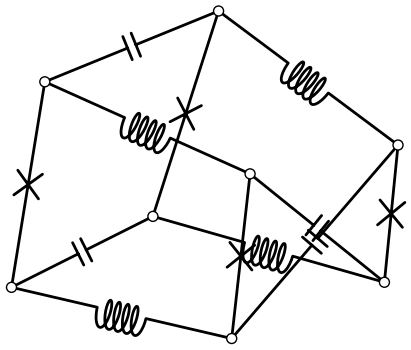

In [ ]:
circuit = [ ("J",), ("J",), ("J",), ("J",),
            ("L",), ("L",), ("L",), ("L",),
            ("C",), ("C",), ("C",), ("C",) ]
edges =   [ (1, 2), (3, 4), (5, 6), (7, 8),
            (1, 5), (2, 6), (4, 8), (3, 7),
            (1, 3), (2, 4), (5, 8), (6, 7) ]
draw_circuit_diagram(circuit, edges, layout="spring")

# match indices with array indices
edges = utils.zero_start_edges(edges)
n_nodes = utils.get_num_nodes(edges)
# labels of mode types
mode_types = []
# dynamical and nondynamical mode vectors
dy_modes = []
nd_modes = []

# sigma -- each set of connected components (should only be 1)
sig_vec = _islands_to_vectors(circuit, edges, [], start_idx=0)
if len(sig_vec) > 1:
    print("--- WARNING: Multiple disconnected circuit segments ---")
# Free -- capacitively shunted islands
free_vec = _islands_to_vectors(circuit, edges, ["C"])
# Frozen -- inductively shunted islands
froz_vec = _islands_to_vectors(circuit, edges, ["L"])

# Compact -- J,C shunted islands
comp_vec = _islands_to_vectors(circuit, edges, ["J", "C"], 0)
# Harmonic -- L,C shunted islands
harm_vec = _islands_to_vectors(circuit, edges, ["L", "C"])

# Extended -> must fill out the junction connectivity
# matrix. Minimize coupling, or maybe project to construct
# elements orthogonal to the harmonic vectors?
# All the compact variables will already be orthogonal from each other.
w = gen_w(circuit, edges, "J")
w_inv = sym.transpose(w.pinv())
w_inv = sym.transpose(w[:, :2].pinv())
jj_basis = comp_vec + [w_inv.col(i) for i in range(w_inv.shape[1]-1)]
cMat = gen_cap_mat(circuit, edges)
lMat = gen_ind_mat(circuit, edges)
# jj_basis = sym.GramSchmidt(jj_basis)

In [311]:
wj = gen_w(circuit, edges, "J")
wl = gen_w(circuit, edges, "L")
wc = gen_w(circuit, edges, "C")
wjl = sym.Matrix.hstack(wj, wl)
wjc = sym.Matrix.hstack(wj, wc)
fm = wjl.transpose().nullspace()
fzm = wjc.transpose().nullspace()

In [291]:
ns = wl.transpose().nullspace()
ns

[Matrix([
 [1],
 [0],
 [0],
 [0],
 [1],
 [0],
 [0],
 [0]]),
 Matrix([
 [0],
 [1],
 [0],
 [0],
 [0],
 [1],
 [0],
 [0]]),
 Matrix([
 [0],
 [0],
 [1],
 [0],
 [0],
 [0],
 [1],
 [0]]),
 Matrix([
 [0],
 [0],
 [0],
 [1],
 [0],
 [0],
 [0],
 [1]])]

In [300]:
pinv = wj.pinv().transpose()
pinv

Matrix([
[ 1/2,    0,    0,    0],
[-1/2,    0,    0,    0],
[   0,  1/2,    0,    0],
[   0, -1/2,    0,    0],
[   0,    0,  1/2,    0],
[   0,    0, -1/2,    0],
[   0,    0,    0,  1/2],
[   0,    0,    0, -1/2]])

In [318]:
ns[1]

Matrix([
[0],
[1],
[0],
[0],
[0],
[1],
[0],
[0]])

In [323]:
ns = wl.transpose().nullspace()
wj_ns = wj.transpose().nullspace()
p1 = ns[1]
# p1[0] = -1
# p1[4] = -1
# p1/=2
p2 = ns[-1]

In [324]:
Z = sym.Matrix.hstack(p1, p2,
                      -pinv[:, 0]-pinv[:,1]+pinv[:,2]-pinv[:,3],
                      -pinv[:, 0]-pinv[:,1]-pinv[:,2]+pinv[:,3],
                      wj_ns[0]+wj_ns[-1], fm[0], fzm[0], fm[0]+fm[1])


display(Z)
# display(Z.inv())
display(wj.transpose()*Z)
ctrans = Z.transpose()*cMat*Z
display(ctrans)
display(Z.transpose()*lMat*Z)

Matrix([
[0, 0, -1/2, -1/2, 1, 1, 1, 1],
[1, 0,  1/2,  1/2, 1, 1, 1, 1],
[0, 0, -1/2, -1/2, 0, 0, 1, 1],
[0, 1,  1/2,  1/2, 0, 0, 1, 1],
[0, 0,  1/2, -1/2, 0, 1, 0, 1],
[1, 0, -1/2,  1/2, 0, 1, 0, 1],
[0, 0, -1/2,  1/2, 1, 0, 0, 1],
[0, 1,  1/2, -1/2, 1, 0, 0, 1]])

Matrix([
[-1,  0, -1, -1, 0, 0, 0, 0],
[ 0, -1, -1, -1, 0, 0, 0, 0],
[-1,  0,  1, -1, 0, 0, 0, 0],
[ 0, -1, -1,  1, 0, 0, 0, 0]])

Matrix([
[2*C + 2*C_{J},            -C,       0, 2*C_{J},   0,  2*C, 0, 0],
[           -C, 2*C + 2*C_{J}, 2*C_{J},       0,   0, -2*C, 0, 0],
[            0,       2*C_{J}, 4*C_{J},       0,   0,    0, 0, 0],
[      2*C_{J},             0,       0, 4*C_{J},   0,    0, 0, 0],
[            0,             0,       0,       0, 4*C,    0, 0, 0],
[          2*C,          -2*C,       0,       0,   0,  4*C, 0, 0],
[            0,             0,       0,       0,   0,    0, 0, 0],
[            0,             0,       0,       0,   0,    0, 0, 0]])

Matrix([
[0, 0,   0,   0,   0, 0,   0, 0],
[0, 0,   0,   0,   0, 0,   0, 0],
[0, 0, 2/L,   0,   0, 0,   0, 0],
[0, 0,   0, 2/L,   0, 0,   0, 0],
[0, 0,   0,   0, 4/L, 0,   0, 0],
[0, 0,   0,   0,   0, 0,   0, 0],
[0, 0,   0,   0,   0, 0, 4/L, 0],
[0, 0,   0,   0,   0, 0,   0, 0]])

In [344]:
def decoupling_transformation(X, divide):

    # Determine which nondynamical variables are coupled to dynamical variables
    n_nd = X.shape[0]-divide
    coupled = []
    for i in range(divide, X.shape[0]):
        if any(X[i, divide:]):
            coupled.append(i)
    
    # Make the transformation to uncouple them
    # (I 0)
    # (M I)
    # with M = -X_22^-1 X_21
    Z2 = sym.eye(X.shape[0])
    X22 = X[coupled, coupled]
    X21 = X[coupled, :divide]
    M = -X22.inv()*X21
    for i, row in enumerate(coupled):
        Z2[row, :divide] = M[i, :]
    return Z2

Z2 = decoupling_transformation(ctrans, 5)
display(Z2)
Z2.transpose()*ctrans*Z2

Matrix([
[   1,   0, 0, 0, 0, 0, 0, 0],
[   0,   1, 0, 0, 0, 0, 0, 0],
[   0,   0, 1, 0, 0, 0, 0, 0],
[   0,   0, 0, 1, 0, 0, 0, 0],
[   0,   0, 0, 0, 1, 0, 0, 0],
[-1/2, 1/2, 0, 0, 0, 1, 0, 0],
[   0,   0, 0, 0, 0, 0, 1, 0],
[   0,   0, 0, 0, 0, 0, 0, 1]])

Matrix([
[C + 2*C_{J},           0,       0, 2*C_{J},   0,   0, 0, 0],
[          0, C + 2*C_{J}, 2*C_{J},       0,   0,   0, 0, 0],
[          0,     2*C_{J}, 4*C_{J},       0,   0,   0, 0, 0],
[    2*C_{J},           0,       0, 4*C_{J},   0,   0, 0, 0],
[          0,           0,       0,       0, 4*C,   0, 0, 0],
[          0,           0,       0,       0,   0, 4*C, 0, 0],
[          0,           0,       0,       0,   0,   0, 0, 0],
[          0,           0,       0,       0,   0,   0, 0, 0]])

In [347]:
Z*Z2

Matrix([
[-1/2, 1/2, -1/2, -1/2, 1, 1, 1, 1],
[ 1/2, 1/2,  1/2,  1/2, 1, 1, 1, 1],
[   0,   0, -1/2, -1/2, 0, 0, 1, 1],
[   0,   1,  1/2,  1/2, 0, 0, 1, 1],
[-1/2, 1/2,  1/2, -1/2, 0, 1, 0, 1],
[ 1/2, 1/2, -1/2,  1/2, 0, 1, 0, 1],
[   0,   0, -1/2,  1/2, 1, 0, 0, 1],
[   0,   1,  1/2, -1/2, 1, 0, 0, 1]])

In [320]:
Z = sym.Matrix.hstack(p1, p2,
                      -pinv[:, 0]-pinv[:,1]+pinv[:,2]-pinv[:,3],
                      -pinv[:, 0]-pinv[:,1]-pinv[:,2]+pinv[:,3],
                      wj_ns[0]+wj_ns[-1], fm[0], fzm[0], fm[0]+fm[1])


display(Z)
# display(Z.inv())
display(wj.transpose()*Z)
ctrans = Z.transpose()*cMat*Z
display(ctrans)
display(Z.transpose()*lMat*Z)

Matrix([
[-1/2, 0, -1/2, -1/2, 1, 1, 1, 1],
[ 1/2, 0,  1/2,  1/2, 1, 1, 1, 1],
[   0, 0, -1/2, -1/2, 0, 0, 1, 1],
[   0, 1,  1/2,  1/2, 0, 0, 1, 1],
[-1/2, 0,  1/2, -1/2, 0, 1, 0, 1],
[ 1/2, 0, -1/2,  1/2, 0, 1, 0, 1],
[   0, 0, -1/2,  1/2, 1, 0, 0, 1],
[   0, 1,  1/2, -1/2, 1, 0, 0, 1]])

Matrix([
[-1,  0, -1, -1, 0, 0, 0, 0],
[ 0, -1, -1, -1, 0, 0, 0, 0],
[-1,  0,  1, -1, 0, 0, 0, 0],
[ 0, -1, -1,  1, 0, 0, 0, 0]])

Matrix([
[C + 2*C_{J},             0,       0, 2*C_{J},   0,    0, 0, 0],
[          0, 2*C + 2*C_{J}, 2*C_{J},       0,   0, -2*C, 0, 0],
[          0,       2*C_{J}, 4*C_{J},       0,   0,    0, 0, 0],
[    2*C_{J},             0,       0, 4*C_{J},   0,    0, 0, 0],
[          0,             0,       0,       0, 4*C,    0, 0, 0],
[          0,          -2*C,       0,       0,   0,  4*C, 0, 0],
[          0,             0,       0,       0,   0,    0, 0, 0],
[          0,             0,       0,       0,   0,    0, 0, 0]])

Matrix([
[0, 0,   0,   0,   0, 0,   0, 0],
[0, 0,   0,   0,   0, 0,   0, 0],
[0, 0, 2/L,   0,   0, 0,   0, 0],
[0, 0,   0, 2/L,   0, 0,   0, 0],
[0, 0,   0,   0, 4/L, 0,   0, 0],
[0, 0,   0,   0,   0, 0,   0, 0],
[0, 0,   0,   0,   0, 0, 4/L, 0],
[0, 0,   0,   0,   0, 0,   0, 0]])

In [ ]:
Z3 = sym.Matrix.vstack(sym.Matrix.hstack(sym.eye(4), sym.zeros(4,2)),
                       sym.Matrix.hstack(ctrans[[4],[4]].inv()*ctrans[4, :4], sym.eye(1), sym.zeros(1,1)),
                        sym.Matrix.hstack(sym.zeros(1,5), sym.eye(1)))
Z3